In [1]:
from itertools import product
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import h5py
from psf_toolbox_v3 import psf_high_NA_vector, render_psf_emitters, scaled_psf_vector
from tqdm import tqdm
from functools import cache
from scipy.stats import entropy
import scipy.ndimage as ndi
cached_scaled_psf_vector = cache(scaled_psf_vector)
cached_scaled_psf_vector.cache_clear()

In [2]:
def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = int((scale-1)/2)
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)

## Generate start pattern synthetic data for testing the resilience to abberations

In [38]:
MONTE_CARLO_SAMPLES = 50

WIDTH = 50
HEIGTH = 50
BCKG = 0
UPSCALE = 4
DEG = np.pi/180.
snrs = 1_000_000
snrs_mc = np.ones(MONTE_CARLO_SAMPLES)*snrs
noise_std = 0

params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES}

def generate_xys(density=5):
    x = np.random.uniform(5, 45, density)
    y = np.random.uniform(5, 45, density)
    return np.vstack((x,y)).T


def add_snr_col(snr, xys):
    """Add third column with SNR to an array of coordinates."""
    n = xys.shape[0]
    return np.hstack([xys, np.ones((n, 1))*snr])



In [39]:
# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)
cwl = 580 #nm

#Helper routines for image generation
def l1norm(img):
    img = (img - np.min(img))
    return img/np.sum(img)
    
def generate_image(xyi, noise_mean, noise_std, psf_factory, h, w, norm=False):
    """
    Generates a 2D image using PSF

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_factory (callable): function that takes index and returns ndarray with psf 
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img0 = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    img_em = np.zeros((50,50), dtype=np.float32)
    for i, (x, y, inten) in enumerate(xyi):        
        r = np.round(np.sqrt((x-25)**2 + (y-25)**2),0)
        psf = psf_factory(r)
        img_em += render_psf_emitters(np.array([(x,y,inten)]), psf, 50, 50)
    img = img0 + np.random.poisson(img_em)
    if not norm:
        return img
    return img/np.sum(img)

In [41]:
px_size_um=0.059*2
NA=1.4
n=1.5
density = 20
slope_factor = 0.75
params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES, 'density' : density, 'slope_factor' : slope_factor}

def my_progressive_defocus(r):
    r0 = 5e-2
    _psf, _dx = cached_scaled_psf_vector(px_size_um, NA, n, wavelength=0.58, A_def = r0 + 0.15*min(slope_factor*r/18, 1))
    return _psf

with h5py.File('data/input_for_cnn_star_variable_psf5_0.h5', 'w') as h5f:       
    ref_dset = h5f.create_dataset('reference', shape=(MONTE_CARLO_SAMPLES, HEIGTH*UPSCALE, WIDTH*UPSCALE), dtype=np.float32)
    test_dset = h5f.create_dataset('stack_test', shape=(MONTE_CARLO_SAMPLES, HEIGTH, WIDTH), dtype=np.float32)
    dset_ref_pos = h5f.create_dataset('reference_pos', shape=(MONTE_CARLO_SAMPLES, density, 2), dtype=np.float32)

    for pkey, val in params.items():
        print(pkey)
        h5f.attrs.create(f'gen_params_{pkey}', val)

    for i in tqdm(range(MONTE_CARLO_SAMPLES)):
        xyi = add_snr_col(1e6, generate_xys(density))
        test_dset[i, :, :] = generate_image(xyi, 0, 0, my_progressive_defocus, HEIGTH, WIDTH, norm = True)
        ref_dset[i, :, :] = generate_gt_image(upscale_xyi(xyi), 200, 200)
        dset_ref_pos[i, :, :] = xyi[:,0:2]


width
height
upscale
noise_std_scale
mc_samples
density
slope_factor


100%|██████████| 50/50 [01:20<00:00,  1.60s/it]


In [42]:
#now we would run process_inputs_cnn_vd.py which outputs cnn_output_star_variable_psf5_0.h5, now we analyze that

In [45]:
# ---------- Metrics ----------
def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        return np.zeros_like(a)
    return asu / norm

def norm_stack(stack):
    return np.array([norm(img) + 1e-10 for img in stack])

def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel())
    if prevent_infty:
        imAn += 1e-10
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel())
    return entropy(imBn / np.sum(imBn), imAn / np.sum(imAn), base=2)

# ---------- Parameters ----------
BLUR = 2
f_metrics = {
   'MAE': lambda x, y: MAE(x, y, BLUR),
   'KLD': lambda x, y: KLD(x, y, BLUR) 
}



In [48]:
fn_input = 'data/cnn_output_star_variable_psf5_0.h5'
transformed_stacks = {}

with h5py.File(fn_input, 'r') as h5f:
    gt_images = np.array(h5f['reference'])
    #compensate systematic shift of CNN
    gt_images = np.roll(gt_images, (1,0), axis=(1,2))
    output_ims = np.array(h5f['stack_test'][:,:,:,0])
    # abber_size = np.array(h5f['param_A_ast']) #range of abberation is the same for all datasets, hence we load any of them and use it for all.


metrics = {}
for mkey, metric_f in f_metrics.items():
    metrics[mkey] = [metric_f(im, imref) for im, imref in zip(output_ims, gt_images)]
    pass
    

In [51]:
plt.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.right': True,
    'axes.spines.top': True,
    'xtick.bottom': True,
    'xtick.labelbottom': True,
    'ytick.left': True,
    'ytick.labelleft': True,
    'lines.linewidth': 1,
    'lines.markersize' : 4,
    'font.size': 11,
    'text.usetex' : True,    
    'font.size': 10,         # Default font size for all text
    'axes.labelsize': 10,    # Labels (x and y axes)
    'xtick.labelsize': 8,    # Tick labels on x-axis
    'ytick.labelsize': 8,    # Tick labels on y-axis
    'legend.fontsize': 9,    # Legend font size
})


# fig, ax = plt.subplots(2, 1, figsize=(4, 2.5), sharex=True)

# for key, axi in zip(metrics, ax):
#     axi.plot(metrics[key], ".-")
#     axi.set_ylabel(key)
# ax[-1].set_xlabel('$\\alpha$ [$\\times 10^{-3}$]')

    
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.17, hspace=0.07)
# # plt.savefig('variable_defocus_vs_rate5_.pdf')
# plt.show()

In [53]:
for key, mdata in metrics.items():
    print(f'{key} = {np.mean(mdata):.3e}+/-{np.std(mdata):.1e}')

MAE = 1.657e-05+/-1.5e-06
KLD = 6.024e-01+/-1.0e-01


In [55]:
with h5py.File('data/input_for_cnn_star_variable_psf5_0.h5', 'r') as h5f:    
    test_dset = np.array(h5f['stack_test'])

In [56]:
#make nice animation

import cv2

def transform_cnn_im_for_vis(im):
    _im = cv2.resize(ndi.gaussian_filter(im, 2), (50,50))
    return _im/np.max(_im)

side_by_side = np.array([np.hstack((a/np.max(a),transform_cnn_im_for_vis(b),transform_cnn_im_for_vis(c))) for a,b,c in zip(test_dset, output_ims, gt_images)])


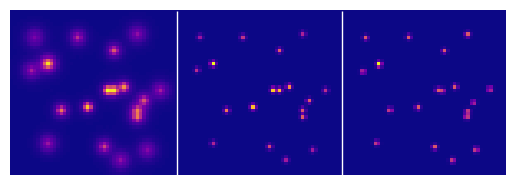

In [58]:
plt.imshow(side_by_side[5], cmap='plasma')
plt.vlines([50,100],0,50,colors='w')
plt.gca().axis('off')
plt.show()

In [ ]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(side_by_side[0], cmap='plasma', vmin=side_by_side.min(), vmax=side_by_side.max())
ax.vlines([50,100],0,50,colors='w')
ax.axis('off')
fig.tight_layout()
def update(frame):
    im.set_data(side_by_side[frame])
    ax.set_title(f'Frame {frame+1}/{len(side_by_side)}', fontsize=10)    
    return [im]

anim = animation.FuncAnimation(fig, update, frames=len(side_by_side), interval=333, blit=True)
anim.save('side_by_side_animation5_0.gif', writer=animation.PillowWriter(fps=3))
plt.close(fig)
print('Saved side_by_side_animation5_0.gif')

Saved side_by_side_animation5_0.gif
